# Modificacion del modelo Hodgkin-Huxley hacia el modelo Fitzhug-Nagumo

Evaluacion de las funciones de disparo, modificacion de la funcion m y comparacion del modelo

In [44]:
import numpy as np
import matplotlib.pyplot as plt

from hh_equations import a_n, b_n, a_m, b_m, a_h, b_h

#plt.style.use('classic')  # Puedes probar otros estilos como 'ggplot' 'bmh', 'classic', etc.


In [32]:
# Constants for the method
Cm = 1                     # membrane capacitance uF/cm^2
dt = 0.01                  # delta time in ms
t = np.arange(0, 60, dt)   # time array in ms

I = 30  # external current applyed

ENa=50      # mv Na reversal potential 
EK=-77      # mv K reversal potential 
El=-54.4    # mv Leakage reversal potential 
gbarNa=120  # mS/cm^2 Na conductance 
gbarK=36    # mS/cm^2 K conductance 
gbarl=0.3   # mS/cm^2 Leakage conductance
V_rest = -60

n = np.zeros(len(t))
m = np.zeros(len(t))
h = np.zeros(len(t))
V = np.zeros(len(t))
V[0] = np.array(V_rest)  # Valor inicial de la solucion

m[0] = a_m(V[0])/(a_m(V[0])+b_m(V[0]))    # Initial m-value
n[0] = a_n(V[0])/(a_n(V[0])+b_n(V[0]))    # Initial n-value
h[0] = a_h(V[0])/(a_h(V[0])+b_h(V[0]))    # Initial h-value


for i in range(0, len(t) - 1):

    # Euler method
    m[i+1]= m[i]+dt*((a_m(V[i])*(1-m[i]))-(b_m(V[i])*m[i]))
    n[i+1]= n[i]+dt*((a_n(V[i])*(1-n[i]))-(b_n(V[i])*n[i])) 
    h[i+1]= h[i]+dt*((a_h(V[i])*(1-h[i]))-(b_h(V[i])*h[i])) 
    
    gNa=gbarNa*h[i]*m[i]**3
    gK=gbarK*n[i]**4
    gl=gbarl
    
    INa=gNa*(V[i]-ENa)
    IK=gK*(V[i]-EK)
    Il=gl*(V[i]-El)
    
    # Euler method to find the next voltage value
    V[i+1]=V[i]+(dt)*((1/Cm)*(I-(INa+IK+Il)))
    


In [33]:

# Constants for the method
Cm = 1                     # membrane capacitance uF/cm^2
dt = 0.01                  # delta time in ms
t = np.arange(0, 60, dt)   # time array in ms

I = 15  # external current applyed

ENa=50      # mv Na reversal potential 
EK=-77      # mv K reversal potential 
El=-54.4    # mv Leakage reversal potential 
gbarNa=120  # mS/cm^2 Na conductance 
gbarK=36    # mS/cm^2 K conductance 
gbarl=0.3   # mS/cm^2 Leakage conductance
V_rest = -60

n_inf = np.zeros(len(t))
m_inf = np.zeros(len(t))
h_inf = np.zeros(len(t))
Vfn = np.zeros(len(t))
Vfn[0] = np.array(V_rest)  # Valor inicial de la solucion

m_inf[0] = a_m(Vfn[0])/(a_m(Vfn[0])+b_m(Vfn[0]))    # Initial m-value
n_inf[0] = a_n(Vfn[0])/(a_n(Vfn[0])+b_n(Vfn[0]))    # Initial n-value
h_inf[0] = a_h(Vfn[0])/(a_h(Vfn[0])+b_h(Vfn[0]))    # Initial h-value


for i in range(0, len(t) - 1):

    # Euler method
    m_inf[i+1]= a_m(Vfn[i])/(a_m(Vfn[i])+b_m(Vfn[i]))   # first assumption
    n_inf[i+1]= n_inf[i]+dt*((a_n(Vfn[i])*(1-n_inf[i]))-(b_n(Vfn[i])*n_inf[i])) 
    h_inf[i+1]= h_inf[i]+dt*((a_h(Vfn[i])*(1-h_inf[i]))-(b_h(Vfn[i])*h_inf[i])) 
    
    gNafn = gbarNa*h_inf[i]*m_inf[i]**3
    gKfn  = gbarK*n_inf[i]**4
    glfn  = gbarl
    
    INa_fn = gNafn*(Vfn[i]-ENa)
    IK_fn  = gKfn*(Vfn[i]-EK)
    Il_fn  = glfn*(Vfn[i]-El)
    
    # Euler method to find the next voltage value
    Vfn[i+1]=Vfn[i]+(dt)*((1/Cm)*(I-(INa_fn+IK_fn+Il_fn)))


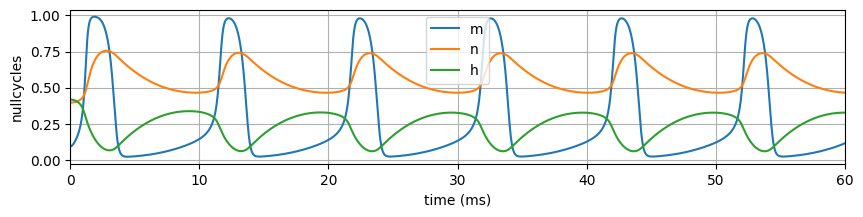

In [34]:
plt.figure(figsize=(10,2))
plt.plot(t, m)
plt.plot(t, n)
plt.plot(t, h)

#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
plt.legend(["m", "n", "h"])
plt.xlabel('time (ms)')
plt.ylabel('nullcycles')
plt.xlim([0,60])
#plt.ylim([-80,40])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

#plt.savefig("output/nullcycles.pdf", format="pdf", bbox_inches="tight")


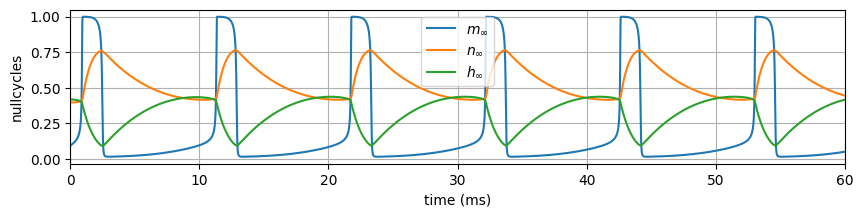

In [35]:
plt.figure(figsize=(10,2))
plt.plot(t, m_inf)
plt.plot(t, n_inf)
plt.plot(t, h_inf)

#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
plt.legend(["$m_\infty$", "$n_\infty$", "$h_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('nullcycles')
plt.xlim([0,60])
#plt.ylim([-80,40])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

#plt.savefig("output/nullcycles.pdf", format="pdf", bbox_inches="tight")

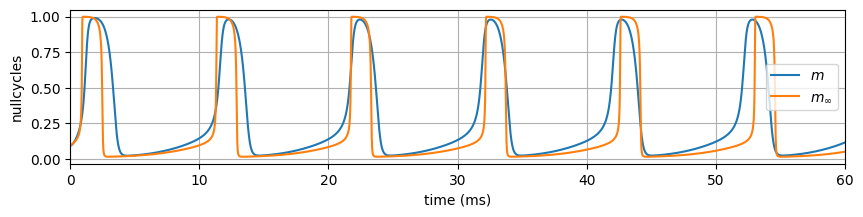

In [36]:
plt.figure(figsize=(10,2))
plt.plot(t, m)
plt.plot(t, m_inf)

#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('nullcycles')
plt.xlim([0,60])
#plt.ylim([-80,40])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

#plt.savefig("output/nullcycles.pdf", format="pdf", bbox_inches="tight")

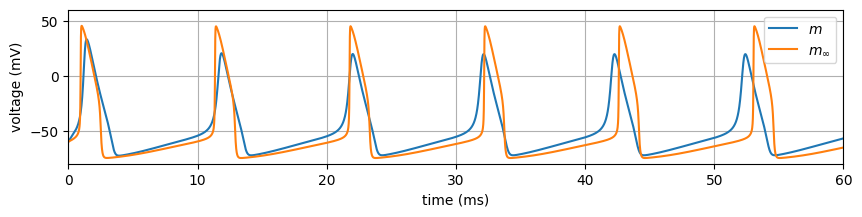

In [42]:
plt.figure(figsize=(10,2))
plt.plot(t, V)
plt.plot(t, Vfn)
#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.xlim([0,60])
plt.ylim([-80,60])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/HHcomparison1.pdf", format="pdf", bbox_inches="tight")


In [38]:
# Evaluacion de las variables para mirar su maxima variacion

V_t = np.arange(-100,40, 0.1)

m_i = (a_m(V_t))/(a_m(V_t)+b_m(V_t))
n_i = (a_n(V_t))/(a_n(V_t)+b_n(V_t))
h_i = (a_h(V_t))/(a_h(V_t)+b_h(V_t))

t_m = 1/(a_m(V_t)+b_m(V_t))
t_n = 1/(a_n(V_t)+b_n(V_t))
t_h = 1/(a_h(V_t)+b_h(V_t))

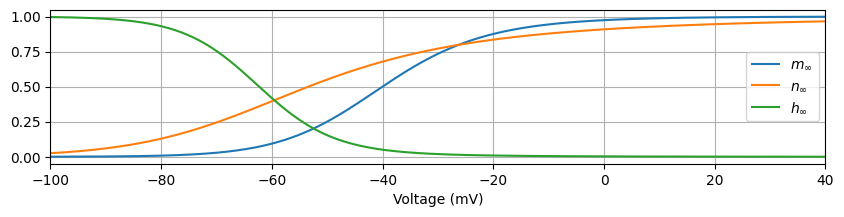

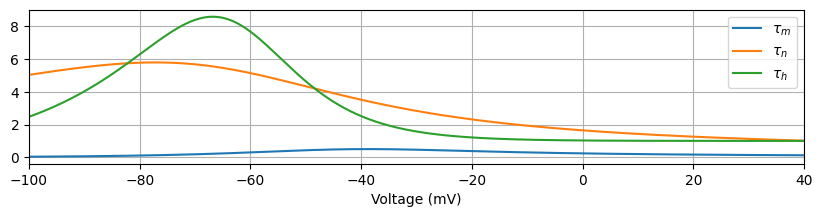

In [39]:
plt.figure(figsize=(10,2))
plt.plot(V_t, m_i)
plt.plot(V_t, n_i)
plt.plot(V_t, h_i)
#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
plt.legend(["$m_\infty$", "$n_\infty$", "$h_\infty$"])
plt.xlabel('Voltage (mV)')
plt.ylabel('')
plt.xlim([-100,40])
#plt.ylim([-80,60])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/shut_inf.pdf", format="pdf", bbox_inches="tight")

## Time variables
plt.figure(figsize=(10,2))
plt.plot(V_t, t_m)
plt.plot(V_t, t_n)
plt.plot(V_t, t_h)
#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
plt.legend([r"$\tau_m$", r"$\tau_n$", r"$\tau_h$"])
plt.xlabel('Voltage (mV)')
plt.ylabel('')
plt.xlim([-100,40])
#plt.ylim([-80,60])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/time_inf.pdf", format="pdf", bbox_inches="tight")